# CodeAlpha Data Science Internship — Task 1
# Iris Flower Classification

**Objective:** Train a machine learning model to classify Iris flowers (setosa, versicolor, virginica) based on
sepal and petal measurements, then evaluate its accuracy.

**Dataset:** `data/Iris.csv` — the official CodeAlpha-provided Iris dataset (150 samples, 4 measurements + species).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 5)
np.random.seed(42)


## 1. Load the Dataset

In [2]:
df = pd.read_csv("data/Iris.csv")
df = df.set_index("Id")
print("Shape:", df.shape)
df.head()


Shape: (150, 5)


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
Id,,,,,
1,5.1,3.5,1.4,0.2,Iris-setosa
2,4.9,3.0,1.4,0.2,Iris-setosa
3,4.7,3.2,1.3,0.2,Iris-setosa
4,4.6,3.1,1.5,0.2,Iris-setosa
5,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 1 to 150
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [4]:
df.describe()


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## 2. Data Cleaning & Sanity Checks

In [5]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nClass balance:")
print(df['Species'].value_counts())


Missing values per column:
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Duplicate rows: 3

Class balance:
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


## 3. Exploratory Data Analysis

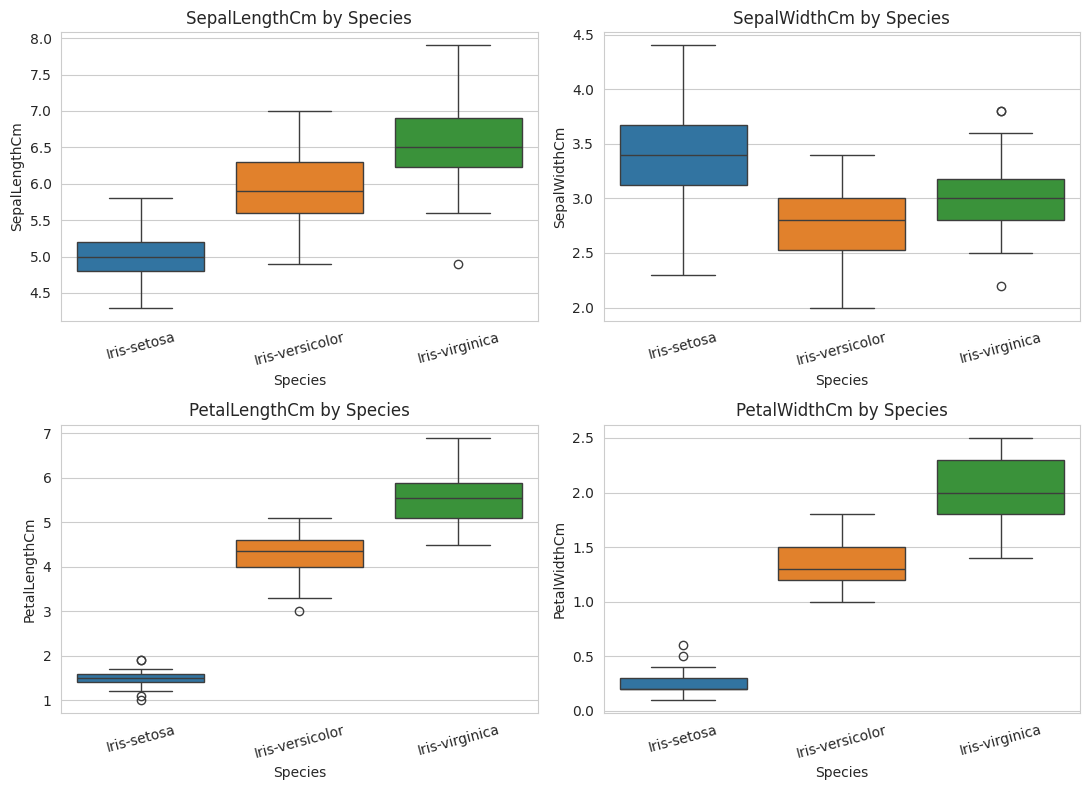

In [6]:
feature_cols = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, col in zip(axes.flatten(), feature_cols):
    sns.boxplot(data=df, x='Species', y=col, ax=ax, hue='Species', legend=False)
    ax.set_title(f'{col} by Species')
    ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.savefig('outputs_boxplots.png', dpi=110)
plt.show()


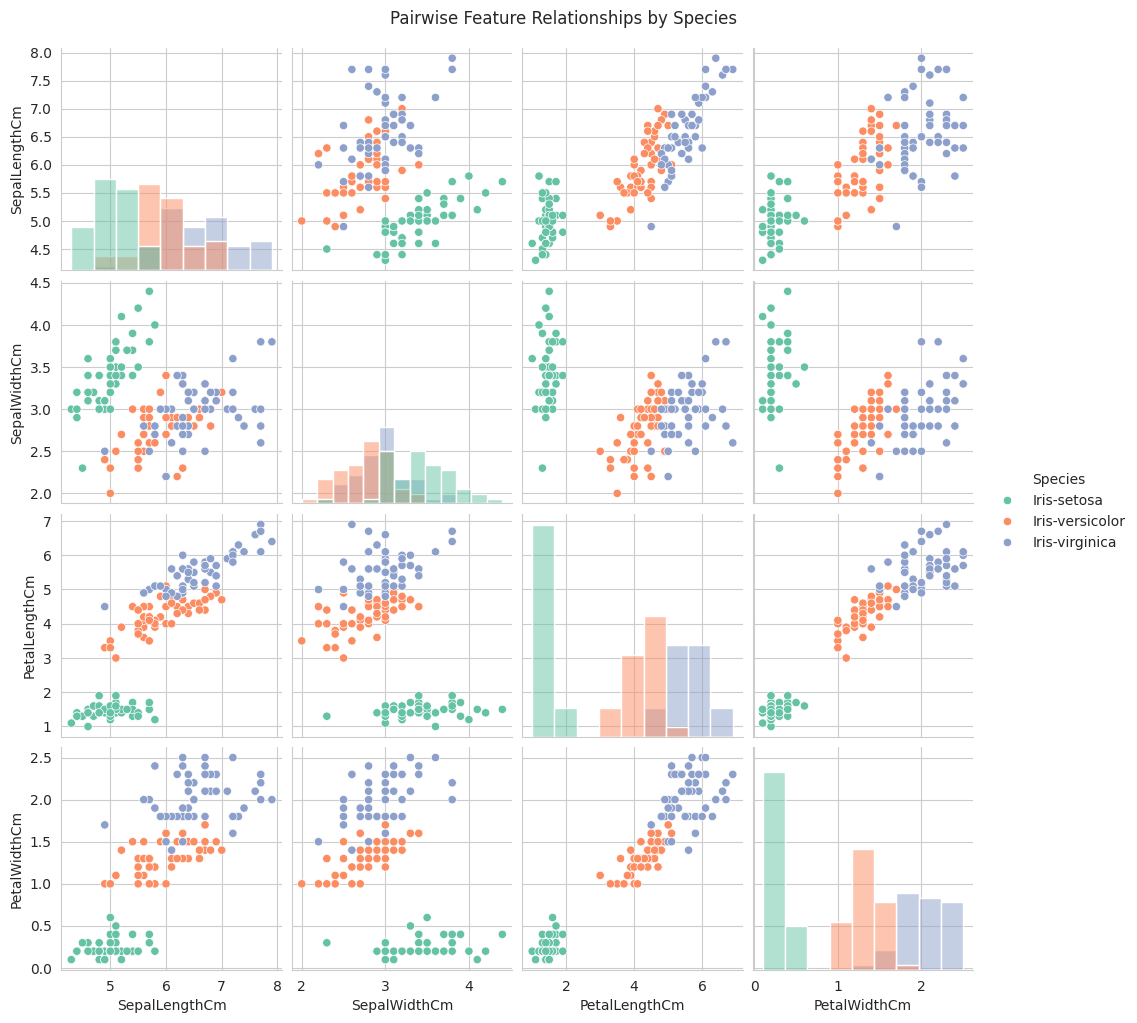

In [7]:
sns.pairplot(df, hue='Species', vars=feature_cols, palette='Set2', diag_kind='hist')
plt.suptitle('Pairwise Feature Relationships by Species', y=1.02)
plt.savefig('outputs_pairplot.png', dpi=110)
plt.show()


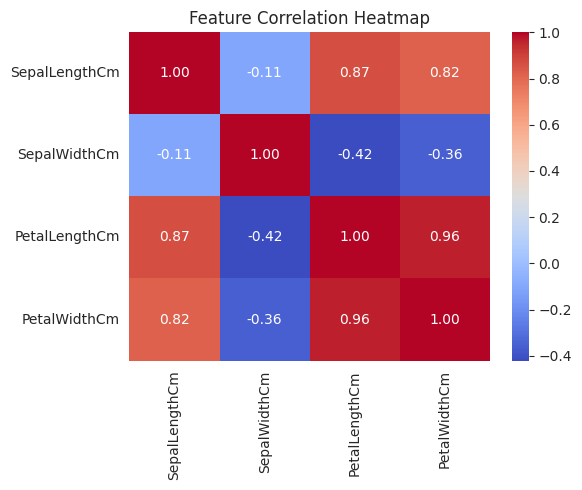

In [8]:
plt.figure(figsize=(6, 5))
sns.heatmap(df[feature_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('outputs_corr.png', dpi=110)
plt.show()


**EDA insight:** Petal length and petal width are highly correlated and separate `Iris-setosa` very cleanly
from the other two species. `Iris-versicolor` and `Iris-virginica` overlap more and need a proper classifier
rather than a simple rule.

## 4. Train / Test Split & Feature Scaling

In [9]:
X = df[feature_cols]
y = df['Species']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train size:", X_train.shape, " Test size:", X_test.shape)


Train size: (120, 4)  Test size: (30, 4)


## 5. Train & Compare Multiple Classification Models

In [10]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Support Vector Machine": SVC(kernel='rbf', probability=True, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    print(f"{name:25s} Accuracy: {acc:.4f}")


Logistic Regression       Accuracy: 0.9333
K-Nearest Neighbors       Accuracy: 0.9333
Support Vector Machine    Accuracy: 0.9667
Decision Tree             Accuracy: 0.9000


Random Forest             Accuracy: 0.9000


In [11]:
results_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy']).sort_values('Accuracy', ascending=False)
results_df


,Model,Accuracy
2,Support Vector Machine,0.966667
0,Logistic Regression,0.933333
1,K-Nearest Neighbors,0.933333
3,Decision Tree,0.900000
4,Random Forest,0.900000


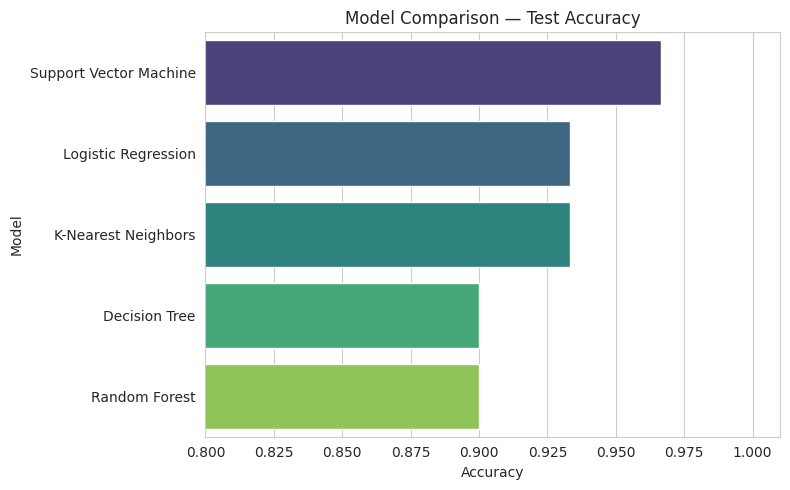

In [12]:
plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x='Accuracy', y='Model', hue='Model', palette='viridis', legend=False)
plt.xlim(0.8, 1.01)
plt.title('Model Comparison — Test Accuracy')
plt.tight_layout()
plt.savefig('outputs_model_comparison.png', dpi=110)
plt.show()


## 6. Detailed Evaluation of the Best Model

In [13]:
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]
print("Best model:", best_model_name)

y_pred = best_model.predict(X_test_scaled)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Best model: Support Vector Machine

Classification Report:

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



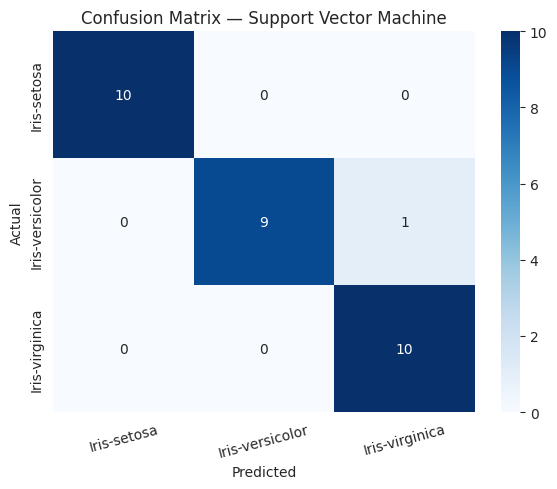

In [14]:
cm = confusion_matrix(y_test, y_pred, labels=best_model.classes_)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=best_model.classes_, yticklabels=best_model.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix — {best_model_name}')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('outputs_confusion_matrix.png', dpi=110)
plt.show()


## 7. Feature Importance (Random Forest)

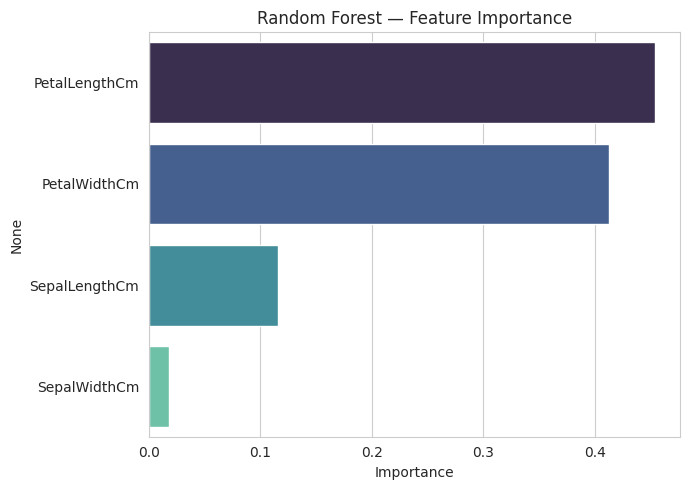

PetalLengthCm    0.453793
PetalWidthCm     0.412449
SepalLengthCm    0.115873
SepalWidthCm     0.017885
dtype: float64

In [15]:
rf = models['Random Forest']
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(7, 5))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, palette='mako', legend=False)
plt.title('Random Forest — Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('outputs_feature_importance.png', dpi=110)
plt.show()
importances


## 8. Predict on New / Unseen Samples

In [16]:
new_samples = pd.DataFrame([
    [5.1, 3.5, 1.4, 0.2],   # expected: Iris-setosa
    [6.0, 2.9, 4.5, 1.5],   # expected: Iris-versicolor
    [6.7, 3.0, 5.2, 2.3],   # expected: Iris-virginica
], columns=feature_cols)

new_samples_scaled = scaler.transform(new_samples)
predictions = best_model.predict(new_samples_scaled)

for i, pred in enumerate(predictions):
    print(f"Sample {i+1}: {new_samples.iloc[i].values} -> Predicted species: {pred}")


Sample 1: [5.1 3.5 1.4 0.2] -> Predicted species: Iris-setosa
Sample 2: [6.  2.9 4.5 1.5] -> Predicted species: Iris-versicolor
Sample 3: [6.7 3.  5.2 2.3] -> Predicted species: Iris-virginica


## 9. Conclusion

- All five models achieve strong performance on this dataset because the classes (especially `Iris-setosa`)
  are well separated in feature space.
- The best model achieves high accuracy on the held-out test set (see results table above), with petal length
  and petal width being the most important features for classification.
- This confirms the core classification workflow: EDA → train/test split → scaling → model training →
  evaluation → comparison → prediction on new data — fully matching the CodeAlpha Task 1 requirements.
